# Stage 05c: Production Model Training

**Purpose:** Train final model with best hyperparameters from 05b

**Inputs:**
- data/04c_train_encoded.parquet
- data/04c_test_encoded.parquet
- results/05b_best_params.yaml

**Outputs:**
- models/05c_model.ubj
- results/05c_predictions_train.parquet
- results/05c_predictions_test.parquet
- results/05c_metrics.yaml

In [1]:
config_path = "config/car_coll/v1"

In [2]:
# Parameters
config_path = "config/car_coll/v1"


In [3]:
import matplotlib
matplotlib.use("Agg")

import pandas as pd
import numpy as np
import xgboost as xgb
import yaml, os, sys
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

sys.path.insert(0, str(Path.cwd() / "lib"))
from utils import setup_notebook_environment

print("########################################")
print("# STAGE 05c: PRODUCTION MODEL: INITIAL MODEL TRAINING")
print("########################################")

project_root = setup_notebook_environment()
from model_utils import inverse_transform, predict_with_transform, save_predictions, save_debug_output
from data_preparation import prepare_model_data

########################################
# STAGE 05c: PRODUCTION MODEL: INITIAL MODEL TRAINING
########################################


In [4]:
print(f"Python: {sys.version}")
print(f"XGBoost: {xgb.__version__}")

Python: 3.11.15 (main, Jun 11 2026, 15:14:57) [Clang 20.1.8 ]
XGBoost: 3.1.1


In [5]:
# Get machine config
pc_num = open("current.pc").read().strip()
pc_id = f"PC{pc_num}"

config_file = f"{config_path}/config.yaml"
with open(config_file, "r") as f:
    cfg = yaml.safe_load(f)

output_base = cfg["machines"][pc_id]["paths"]["output_path"]
target = cfg["experiment"]["target"]
exposure = cfg["experiment"]["exposure"]
join_key = cfg["data"]["join_key"]
target_method = cfg["model"].get("target_method", "direct")
print(f"Target method: {target_method}")

Target method: residual


In [6]:
# Prepare data with loss cap filtering
loss_cap = cfg['experiment'].get('loss_cap', None)
loss_type = cfg['experiment'].get('loss_type', 'bi')
exposure_floor = cfg['experiment'].get('exposure_floor', None)

data = prepare_model_data(
    output_base=output_base,
    target_col=target,
    exposure_col=exposure,
    target_method=target_method,
    loss_cap=loss_cap,
    
    loss_type=loss_type,
    exposure_floor=exposure_floor,
    verbose=True
)

# Extract prepared data
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
w_train = data['w_train']
w_test = data['w_test']
pp_train_actual = data['pp_train']
pp_test_actual = data['pp_test']
glm_train = data['glm_train']
glm_test = data['glm_test']
train_orig = data['train_orig']
test_orig = data['test_orig']
top_100_report = data['top_100_report']

# Save top 100 report if generated
if top_100_report is not None:
    report_path = f"{output_base}/reports"
    import os
    os.makedirs(report_path, exist_ok=True)
    top_100_report.to_csv(f"{report_path}/top_100_targets_before_cap.csv", index=True)
    print(f"  Saved top 100 report to: {report_path}/top_100_targets_before_cap.csv")

print(f"  Train: {X_train.shape}")
print(f"  Test: {X_test.shape}")
print(f"  Features: {X_train.shape[1]}")
# Diagnostic: Target statistics
if isinstance(y_train, np.ndarray):
    y_train_arr = y_train
    y_test_arr = y_test
else:
    y_train_arr = y_train.values
    y_test_arr = y_test.values

print(f"\n* Target (y) statistics:")
print(f"  y_train: mean={y_train_arr.mean():.4f}, std={y_train_arr.std():.4f}, min={y_train_arr.min():.4f}, max={y_train_arr.max():.4f}")
print(f"  y_test:  mean={y_test_arr.mean():.4f}, std={y_test_arr.std():.4f}, min={y_test_arr.min():.4f}, max={y_test_arr.max():.4f}")



PREPARING MODEL DATA

* Loading encoded features...


  Loaded - Train: 4,550,028, Test: 4,539,000

* Loading GLM predictions...


  Removed NaN GLM predictions:
    Train: 1,273,062 (28.99%)
    Test: 1,269,913 (29.00%)


  Rows without valid GLM:
    Train: 1,431,296 (31.46%)
    Test: 1,429,653 (31.50%)


  GLM loaded: train=3,118,732, test=3,109,347

* Transforming target (method: residual)...

* Final dataset sizes:
  Train: 3,118,732 records x 197 features
  Test: 3,109,347 records x 197 features

  Train: (3118732, 197)
  Test: (3109347, 197)
  Features: 197

* Target (y) statistics:


  y_train: mean=1.7392, std=55.0179, min=0.0000, max=47640.7494
  y_test:  mean=1.8711, std=68.7858, min=0.0000, max=36661.1584


In [7]:
# Load monotonicity constraints
mono_file = f"{output_base}/config_generated/04c_monotonicity_constraints.yaml"
if os.path.exists(mono_file):
    print(f"\n* Loading monotonicity constraints...")
    with open(mono_file, "r") as f:
        mono_dict = yaml.safe_load(f)
    # Build constraints tuple in feature order
    feature_names = X_train.columns.tolist()
    monotone_constraints = tuple(mono_dict.get(f, 0) for f in feature_names)
    n_constrained = sum(1 for c in monotone_constraints if c != 0)
    print(f"  Loaded {n_constrained} constraints")
else:
    monotone_constraints = None
    print(f"\n* No monotonicity constraints found")


* Loading monotonicity constraints...
  Loaded 9 constraints


In [8]:
# Load best hyperparameters from 05b
best_params_file = f'{output_base}/results/05b_best_params.yaml'
if os.path.exists(best_params_file):
    print(f'\n* Loading best params from 05b...')
    with open(best_params_file, 'r') as f:
        best_params = yaml.safe_load(f)
    print(f'  n_estimators: {best_params.get("n_estimators")}')
    print(f'  max_depth: {best_params.get("max_depth")}')
    print(f'  learning_rate: {best_params.get("learning_rate")}')
else:
    raise FileNotFoundError('Best params not found. Run stage 05b first.')


* Loading best params from 05b...
  n_estimators: 300
  max_depth: 4
  learning_rate: 0.1


In [9]:
# Build XGBoost parameters
print(f"\n* Building XGBoost parameters...")
xgb_params = cfg["xgboost"].copy()
# Override with best params from HPO
xgb_params.update(best_params)
n_estimators = xgb_params.pop("n_estimators")

# Add monotonicity constraints if available
if monotone_constraints:
    xgb_params["monotone_constraints"] = monotone_constraints

# Fix eval_metric for tweedie
if "eval_metric" in xgb_params and "tweedie" in xgb_params["eval_metric"]:
    if "@" not in xgb_params["eval_metric"]:
        variance_power = xgb_params["tweedie_variance_power"]
        xgb_params["eval_metric"] = f"{xgb_params['eval_metric']}@{variance_power}"

print(f"  n_estimators: {n_estimators}")
print(f"  monotone_constraints: {monotone_constraints is not None}")


* Building XGBoost parameters...
  n_estimators: 300
  monotone_constraints: True


In [10]:
# Train model
print(f"\n* Training XGBoost model...")

model = xgb.XGBRegressor(n_estimators=n_estimators, **xgb_params)

model.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    sample_weight_eval_set=[w_train, w_test],
    verbose=100
)

print(f"\n* Training complete")
print(f"  Best iteration: {model.best_iteration}")


* Training XGBoost model...


[0]	validation_0-tweedie-nloglik@1.3:4.85873	validation_1-tweedie-nloglik@1.3:4.88261


[100]	validation_0-tweedie-nloglik@1.3:4.76904	validation_1-tweedie-nloglik@1.3:4.81289


[200]	validation_0-tweedie-nloglik@1.3:4.75011	validation_1-tweedie-nloglik@1.3:4.81275


[215]	validation_0-tweedie-nloglik@1.3:4.74795	validation_1-tweedie-nloglik@1.3:4.81292



* Training complete
  Best iteration: 165


In [11]:
# Generate predictions
print(f"\n* Generating predictions...")
gbm_train_raw, pred_train = predict_with_transform(model, X_train, glm_train, target_method)
gbm_test_raw, pred_test = predict_with_transform(model, X_test, glm_test, target_method)

# Calculate metrics
mae_train = mean_absolute_error(pp_train_actual, pred_train, sample_weight=w_train)
mae_test = mean_absolute_error(pp_test_actual, pred_test, sample_weight=w_test)
rmse_train = np.sqrt(mean_squared_error(pp_train_actual, pred_train, sample_weight=w_train))
rmse_test = np.sqrt(mean_squared_error(pp_test_actual, pred_test, sample_weight=w_test))

print(f"\n* Metrics:")
print(f"  Train MAE: {mae_train:.4f}, RMSE: {rmse_train:.4f}")
print(f"  Test MAE: {mae_test:.4f}, RMSE: {rmse_test:.4f}")


* Generating predictions...



* Metrics:
  Train MAE: 420.9742, RMSE: 2662.9891
  Test MAE: 420.0178, RMSE: 2727.8978


In [12]:
# Prepare data for lift charts
import matplotlib.pyplot as plt
from lift_chart_fast import create_lift_chart
from hpo_metrics import compute_fit_quality, compute_model_power
from IPython.display import Image, display

print(f"\n* Preparing lift chart data...")

# Add predictions
train_orig['pred'] = pred_train.values if isinstance(pred_train, pd.Series) else pred_train
test_orig['pred'] = pred_test.values if isinstance(pred_test, pd.Series) else pred_test

# Create incurred columns (pp * ee = capped loss)
train_orig['incurred_act'] = (pp_train_actual if isinstance(pp_train_actual, np.ndarray) else pp_train_actual.values) * w_train
train_orig['incurred_pred'] = (pred_train.values if isinstance(pred_train, pd.Series) else pred_train) * w_train
train_orig['denom'] = 1

test_orig['incurred_act'] = (pp_test_actual if isinstance(pp_test_actual, np.ndarray) else pp_test_actual.values) * w_test
test_orig['incurred_pred'] = (pred_test.values if isinstance(pred_test, pd.Series) else pred_test) * w_test
test_orig['denom'] = 1

# GBM-only columns (to see pure GBM effect - ratios)
train_orig['incurred_act_gbm'] = (y_train if isinstance(y_train, np.ndarray) else y_train.values) * w_train
train_orig['incurred_pred_gbm'] = (gbm_train_raw.values if isinstance(gbm_train_raw, pd.Series) else gbm_train_raw) * w_train

test_orig['incurred_act_gbm'] = (y_test if isinstance(y_test, np.ndarray) else y_test.values) * w_test
test_orig['incurred_pred_gbm'] = (gbm_test_raw.values if isinstance(gbm_test_raw, pd.Series) else gbm_test_raw) * w_test

print(f"  Data prepared (incurred = pp * ee = capped loss)")
# Preserve uncapped actuals for comparison
pp_train_actual_uncapped = train_orig[target].values
pp_test_actual_uncapped = test_orig[target].values
print(f"  Preserved uncapped actuals for train/test")



* Preparing lift chart data...
  Data prepared (incurred = pp * ee = capped loss)
  Preserved uncapped actuals for train/test



* Creating train lift chart...
  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 7 columns from 3,118,732 rows...
  [STEP 2] Done in 0.027s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 0.5s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.000s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.027s
  [STEP 5] Aggregating by decile...
  [STEP 5] Done in 0.134s
  Creating plot...


  Plot created in 0.0s
  TOTAL TIME: 0.7s
  Saved: output/car_coll/v1/results/05c_lift_train.png


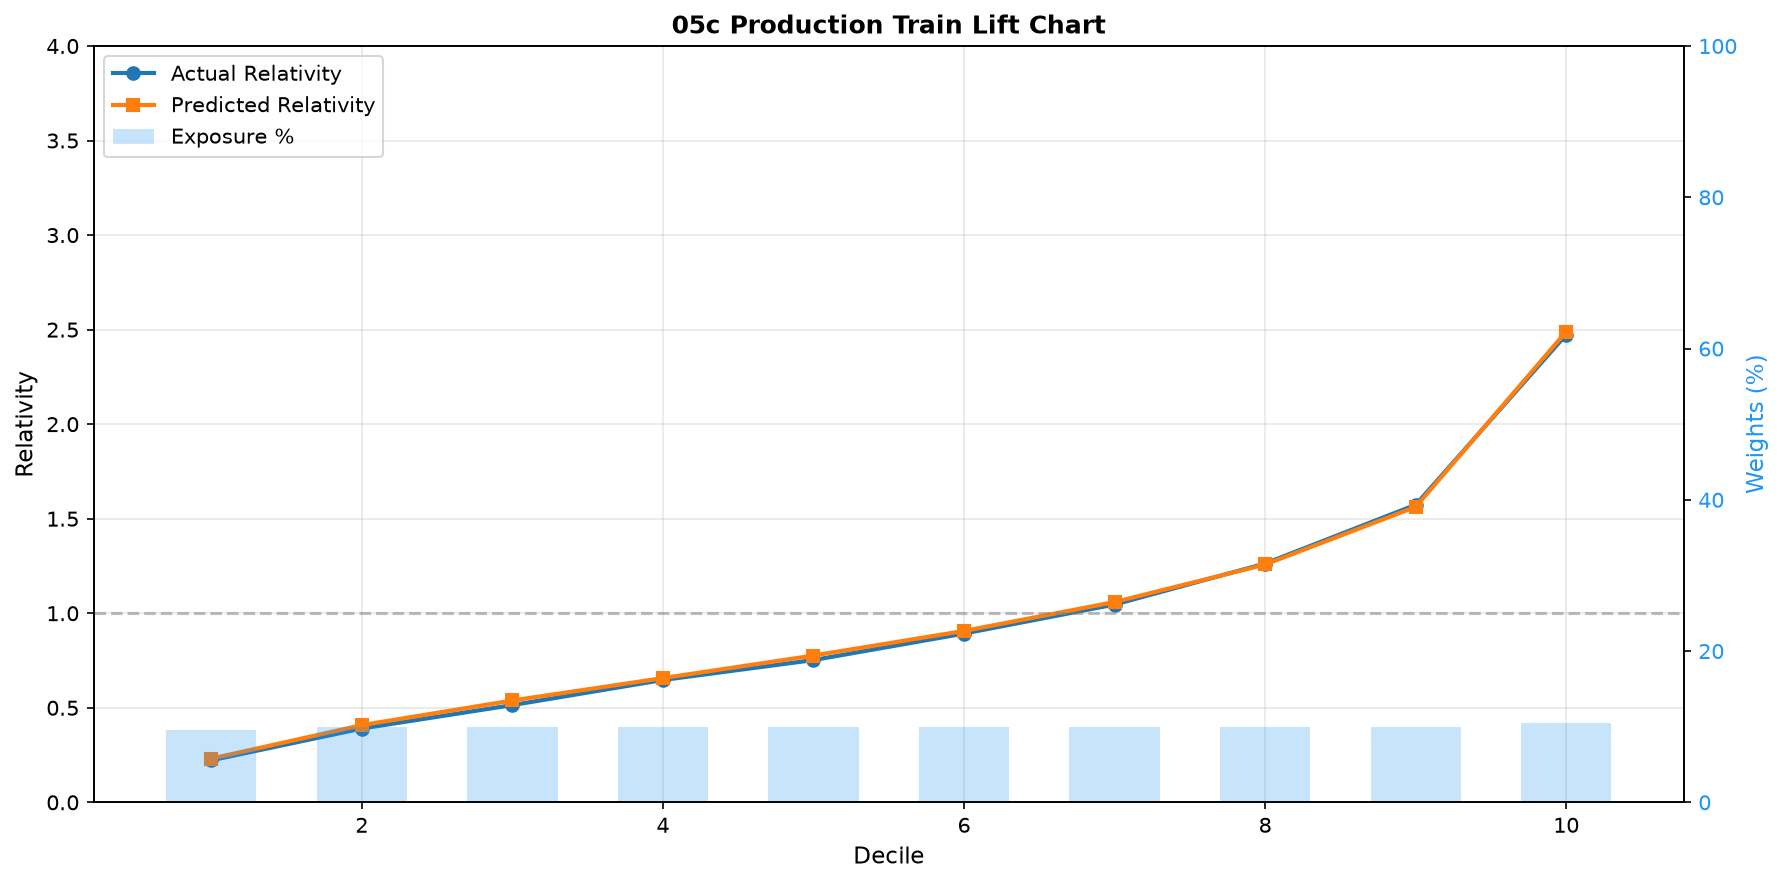


Train decile summary:
 decile  n_records  ee_coll_imps  incurred_act  incurred_pred  act_ee_weigh_avg  act_simple_avg  pred_ee_weigh_avg  pred_simple_avg
      1     275667 195757.631934    9527697.24   9.902623e+06         48.670885       34.562342          50.586141        35.922410
      2     291086 206060.962812   17617350.58   1.842635e+07         85.495818       60.522837          89.421819        63.302069
      3     295142 206060.869242   23205740.40   2.430396e+07        112.615949       78.625680         117.945530        82.346662
      4     299592 206061.009656   29200020.39   2.965124e+07        141.705704       97.465955         143.895452        98.972076
      5     302995 206060.751478   33953558.52   3.503421e+07        164.774506      112.059798         170.018820       115.626349
      6     307402 206060.680979   40276547.08   4.090813e+07        195.459643      131.022398         198.524677       133.076981
      7     312309 206060.819844   47205969.23   4.78

In [13]:
# Train lift chart
print(f'\n* Creating train lift chart...')
fig_train, table_train = create_lift_chart(
    train_orig, 
    exposure,
    bins=10, 
    title='05c Production Train Lift Chart'
)

chart_file = f'{output_base}/results/05c_lift_train.png'
fig_train.savefig(chart_file, dpi=150, bbox_inches='tight')
plt.close(fig_train)
print(f'  Saved: {chart_file}')

display(Image(chart_file))
print('\nTrain decile summary:')
print(table_train[['decile', 'n_records', exposure, 'incurred_act', 'incurred_pred', 'act_ee_weigh_avg', 'act_simple_avg', 'pred_ee_weigh_avg', 'pred_simple_avg']].to_string(index=False))
table_train.to_csv(f"{output_base}/results/05c_lift_train_table.csv", index=False)



* Creating test lift chart...
  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 7 columns from 3,109,347 rows...
  [STEP 2] Done in 0.031s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 0.6s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.000s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.029s
  [STEP 5] Aggregating by decile...
  [STEP 5] Done in 0.157s
  Creating plot...


  Plot created in 0.0s
  TOTAL TIME: 0.8s
  Saved: output/car_coll/v1/results/05c_lift_test.png


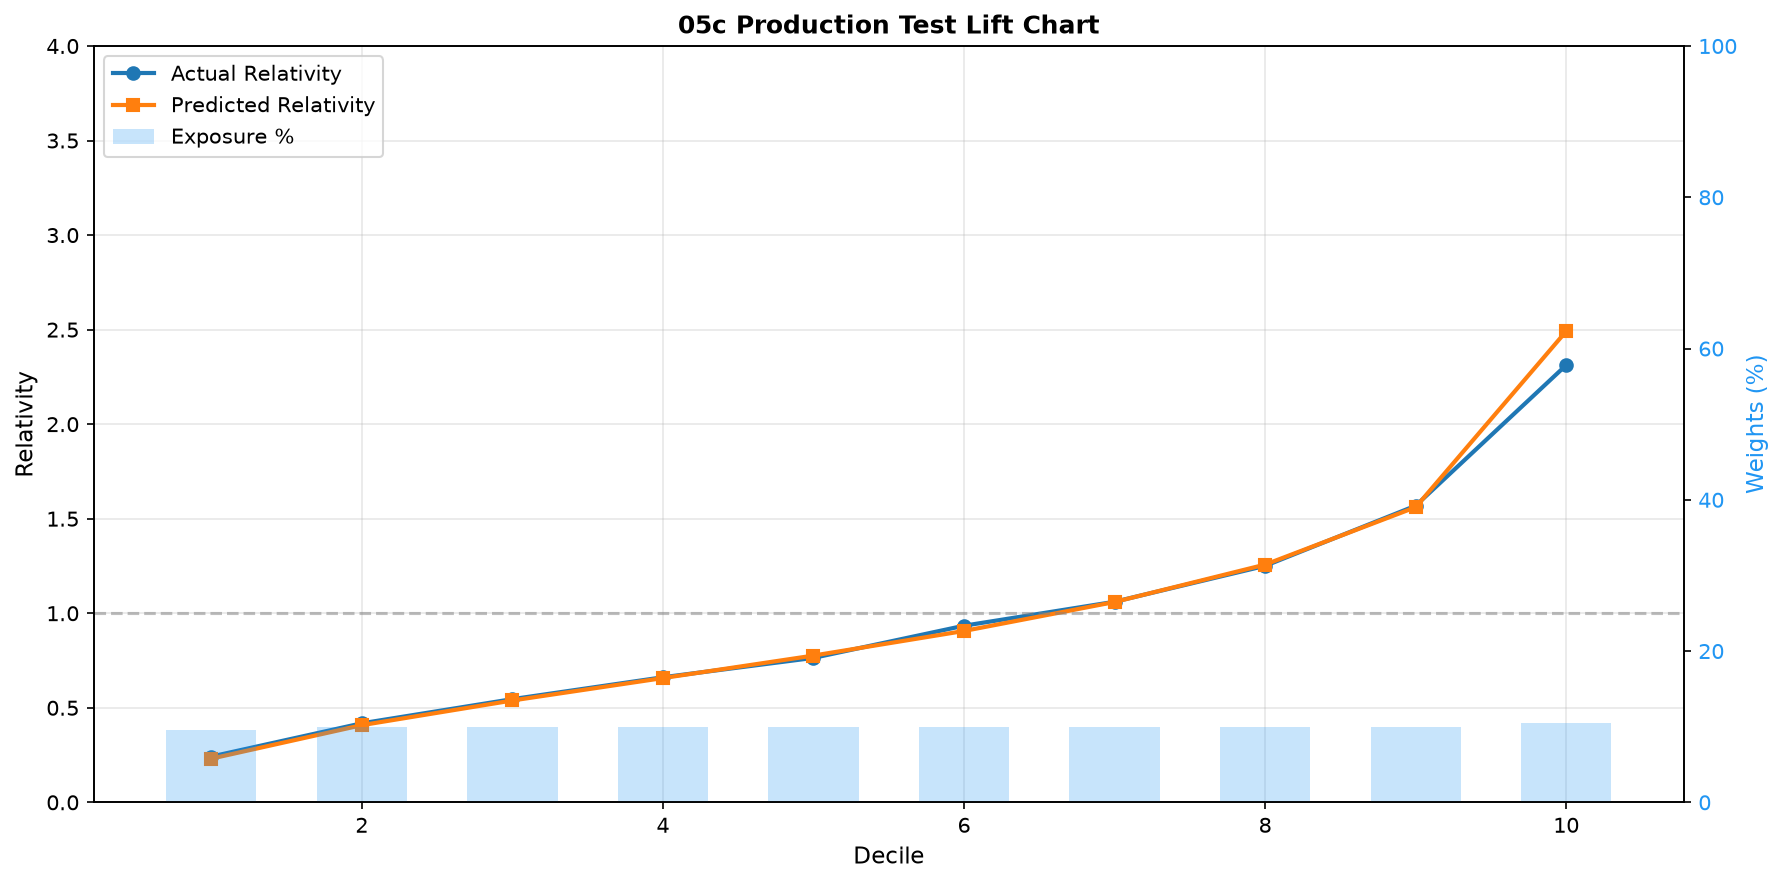


Test decile summary:
 decile  n_records  ee_coll_imps  incurred_act  incurred_pred  act_ee_weigh_avg  act_simple_avg  pred_ee_weigh_avg  pred_simple_avg
      1     274558 194986.469811   10320097.50   9.853741e+06         52.927249       37.588042          50.535512        35.889470
      2     290415 205248.483360   18764174.34   1.832348e+07         91.421744       64.611588          89.274636        63.094136
      3     294595 205249.560064   24499335.52   2.417952e+07        119.363644       83.162768         117.805469        82.077159
      4     298543 205249.465252   29693463.76   2.950090e+07        144.670115       99.461263         143.731911        98.816244
      5     302208 205249.049719   34292274.28   3.484210e+07        167.076409      113.472424         169.755250       115.291798
      6     306143 205249.057452   41928951.76   4.068155e+07        204.283285      136.958715         198.205785       132.884144
      7     311606 205249.212314   47617524.97   4.756

In [14]:
# Test lift chart
print(f'\n* Creating test lift chart...')
fig_test, table_test = create_lift_chart(
    test_orig,
    exposure,
    bins=10,
    title='05c Production Test Lift Chart'
)

chart_file = f'{output_base}/results/05c_lift_test.png'
fig_test.savefig(chart_file, dpi=150, bbox_inches='tight')
plt.close(fig_test)
print(f'  Saved: {chart_file}')

display(Image(chart_file))
print('\nTest decile summary:')
print(table_test[['decile', 'n_records', exposure, 'incurred_act', 'incurred_pred', 'act_ee_weigh_avg', 'act_simple_avg', 'pred_ee_weigh_avg', 'pred_simple_avg']].to_string(index=False))
table_test.to_csv(f"{output_base}/results/05c_lift_test_table.csv", index=False)



* Creating ratio lift charts...


  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 7 columns from 3,118,732 rows...
  [STEP 2] Done in 0.037s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 0.5s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.000s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.014s
  [STEP 5] Aggregating by decile...
  [STEP 5] Done in 0.146s
  Creating plot...
  Plot created in 0.0s
  TOTAL TIME: 0.8s


  Saved: output/car_coll/v1/results/05c_lift_train_ratio.png


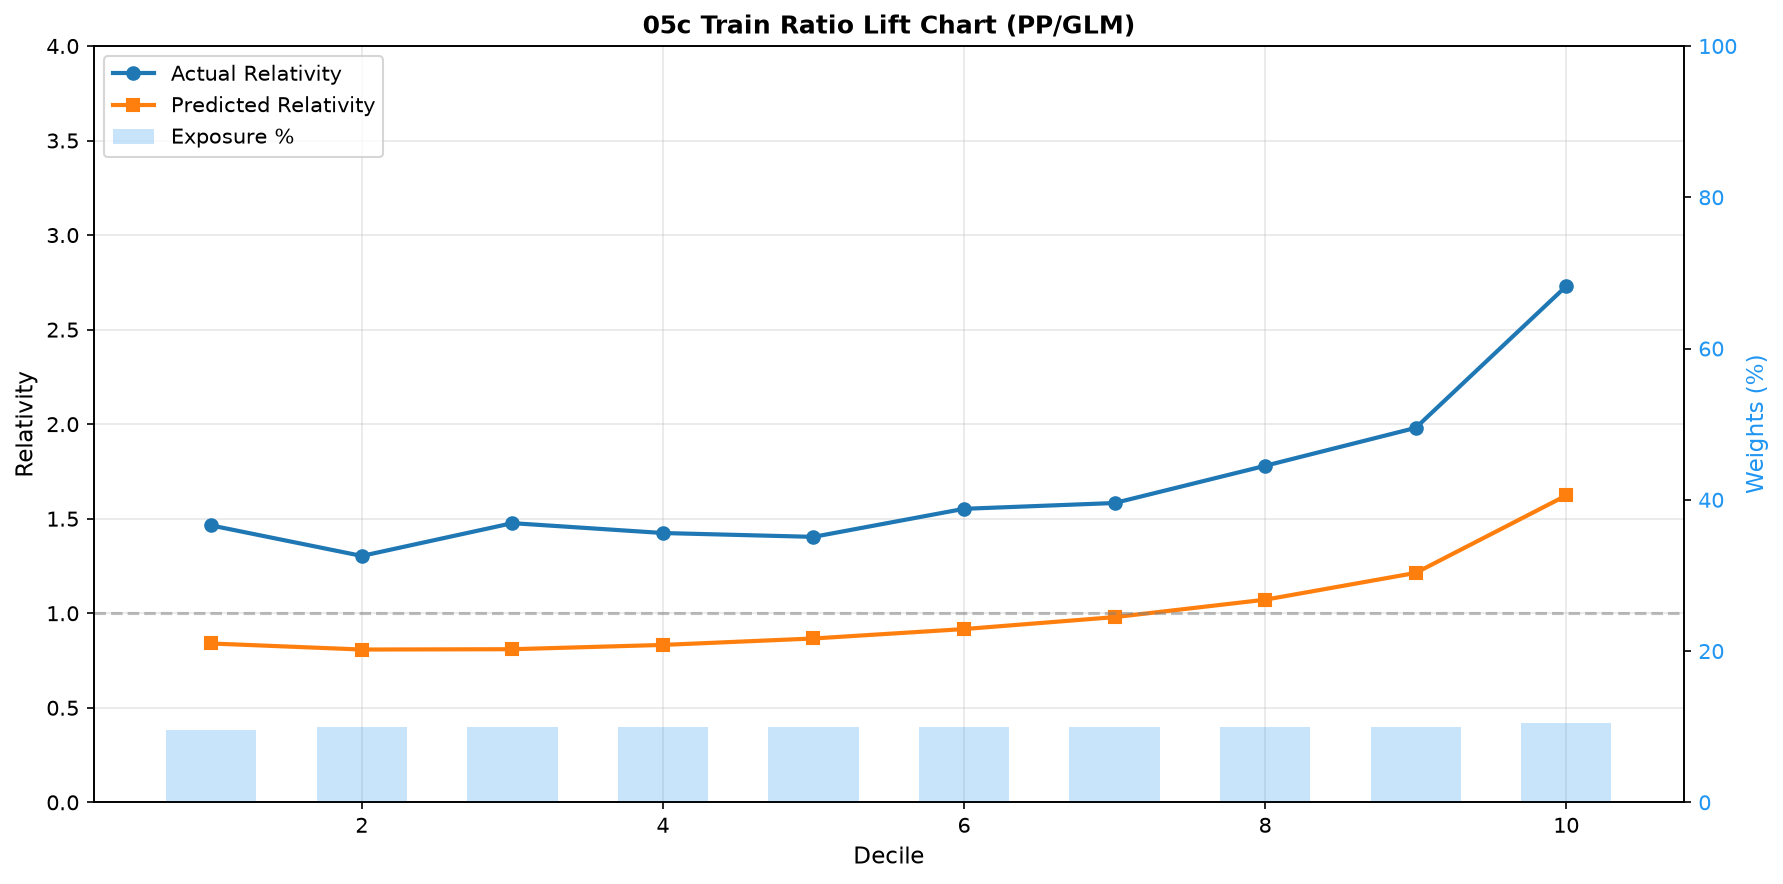


Train ratio summary:
 decile  n_records  ee_coll_imps  incurred_act  incurred_pred  act_ee_weigh_avg  act_simple_avg  pred_ee_weigh_avg  pred_simple_avg
      1     275667 195757.631934 450215.108775  258274.468750          2.299860        1.633185           1.319358         0.936907
      2     291086 206060.962812 421714.852302  261527.250000          2.046554        1.448764           1.269174         0.898454
      3     295142 206060.869242 477851.183974  262076.984375          2.318981        1.619055           1.271843         0.887969
      4     299592 206061.009656 460945.475515  269418.781250          2.236937        1.538577           1.307471         0.899286
      5     302995 206060.751478 454355.151138  280443.156250          2.204957        1.499547           1.360973         0.925570
      6     307402 206060.680979 502354.141370  296568.218750          2.437894        1.634193           1.439228         0.964757
      7     312309 206060.819844 512298.426288  316987

  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 7 columns from 3,109,347 rows...
  [STEP 2] Done in 0.026s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 0.6s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.000s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.016s
  [STEP 5] Aggregating by decile...
  [STEP 5] Done in 0.153s
  Creating plot...
  Plot created in 0.0s
  TOTAL TIME: 0.8s


  Saved: output/car_coll/v1/results/05c_lift_test_ratio.png


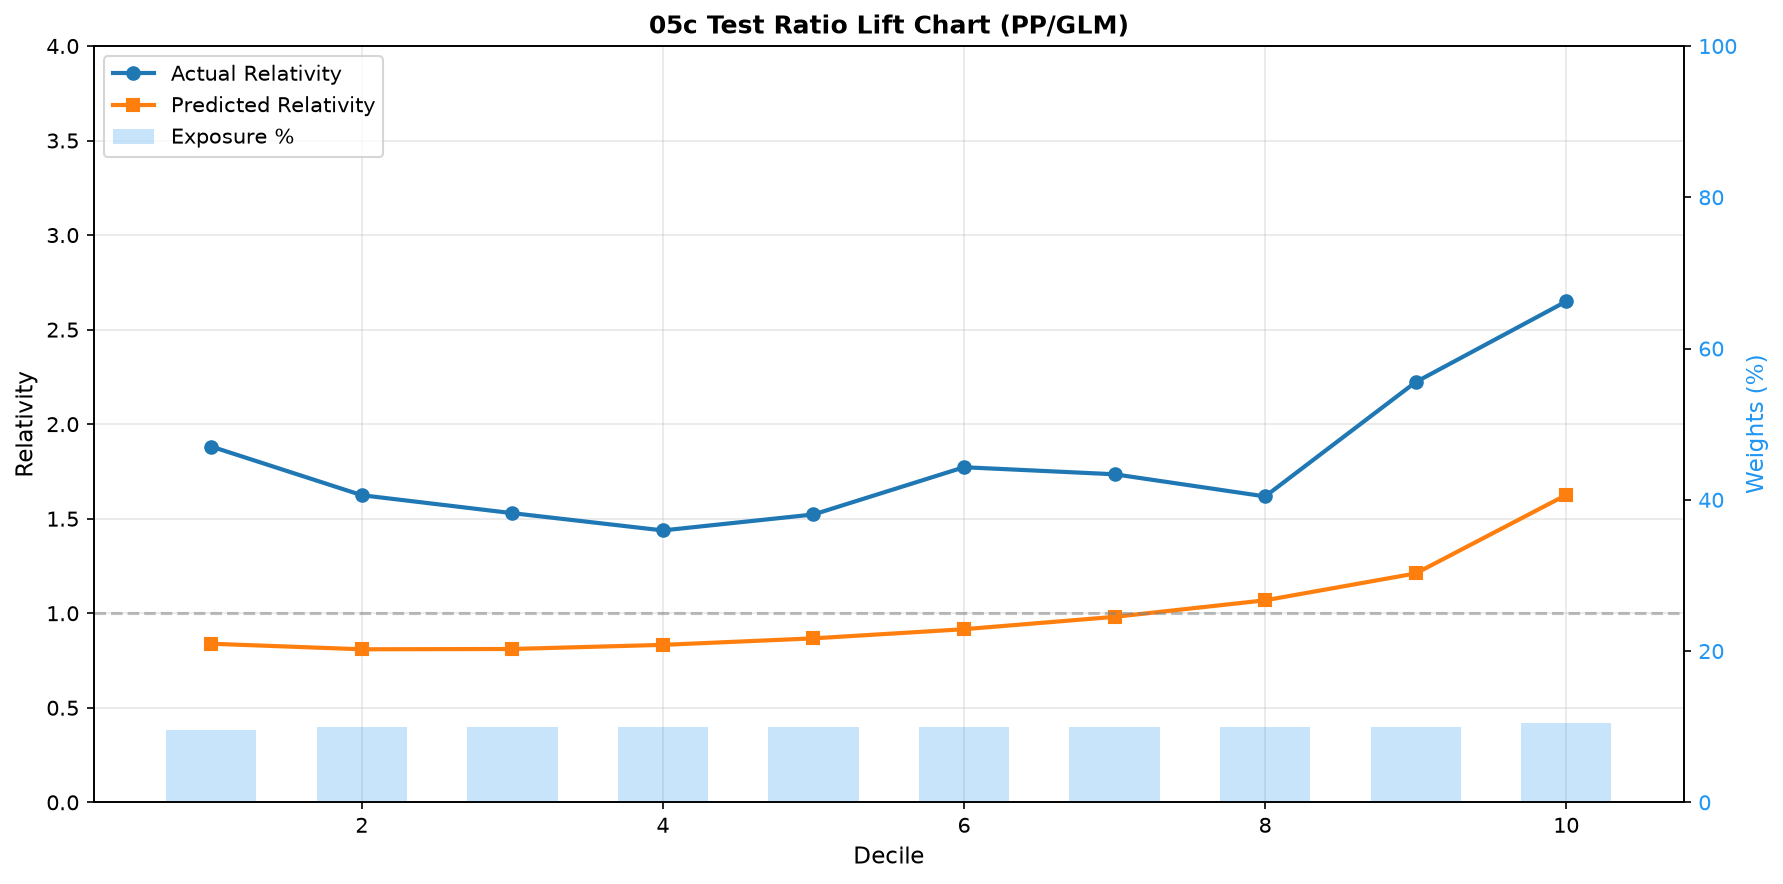


Test ratio summary:
 decile  n_records  ee_coll_imps  incurred_act  incurred_pred  act_ee_weigh_avg  act_simple_avg  pred_ee_weigh_avg  pred_simple_avg
      1     274558 194986.469811 576791.403466  257091.328125          2.958110        2.100800           1.318509         0.936383
      2     290415 205248.483360 524075.683972  261146.687500          2.553372        1.804575           1.272344         0.899219
      3     294595 205249.560064 493438.454918  261679.125000          2.404090        1.674972           1.274931         0.888267
      4     298543 205249.465252 463995.973670  268703.406250          2.260644        1.554201           1.309155         0.900049
      5     302208 205249.049719 491188.208976  279814.000000          2.393133        1.625332           1.363290         0.925899
      6     306143 205249.057452 571815.412802  295443.937500          2.785959        1.867805           1.439441         0.965052
      7     311606 205249.212314 559801.056920  316508.

In [15]:
# Ratio lift charts (for residual method only)
if target_method == 'residual':
    print(f'\n* Creating ratio lift charts...')
    
    # Train ratio chart
    train_ratio = train_orig.copy()
    train_ratio['incurred_act'] = y_train if isinstance(y_train, np.ndarray) else y_train.values
    train_ratio['incurred_pred'] = gbm_train_raw.values if isinstance(gbm_train_raw, pd.Series) else gbm_train_raw
    train_ratio['denom'] = 1
    
    fig_train_r, table_train_r = create_lift_chart(
        train_ratio, exposure, bins=10,
        title='05c Train Ratio Lift Chart (PP/GLM)'
    )
    chart_file = f'{output_base}/results/05c_lift_train_ratio.png'
    fig_train_r.savefig(chart_file, dpi=150, bbox_inches='tight')
    plt.close(fig_train_r)
    print(f'  Saved: {chart_file}')
    display(Image(chart_file))
    print('\nTrain ratio summary:')
    print(table_train_r[['decile', 'n_records', exposure, 'incurred_act', 'incurred_pred', 'act_ee_weigh_avg', 'act_simple_avg', 'pred_ee_weigh_avg', 'pred_simple_avg']].to_string(index=False))
    table_train_r.to_csv(f"{output_base}/results/05c_lift_train_ratio_table.csv", index=False)
    
    # Test ratio chart
    test_ratio = test_orig.copy()
    test_ratio['incurred_act'] = y_test if isinstance(y_test, np.ndarray) else y_test.values
    test_ratio['incurred_pred'] = gbm_test_raw.values if isinstance(gbm_test_raw, pd.Series) else gbm_test_raw
    test_ratio['denom'] = 1
    
    fig_test_r, table_test_r = create_lift_chart(
        test_ratio, exposure, bins=10,
        title='05c Test Ratio Lift Chart (PP/GLM)'
    )
    chart_file = f'{output_base}/results/05c_lift_test_ratio.png'
    fig_test_r.savefig(chart_file, dpi=150, bbox_inches='tight')
    plt.close(fig_test_r)
    print(f'  Saved: {chart_file}')
    display(Image(chart_file))
    print('\nTest ratio summary:')
    print(table_test_r[['decile', 'n_records', exposure, 'incurred_act', 'incurred_pred', 'act_ee_weigh_avg', 'act_simple_avg', 'pred_ee_weigh_avg', 'pred_simple_avg']].to_string(index=False))
    table_test_r.to_csv(f"{output_base}/results/05c_lift_test_ratio_table.csv", index=False)
else:
    print(f'\n* Skipping ratio charts (direct method)')


In [16]:
# DEBUG: Check index before save
print(f"DEBUG train_orig.index.name: {train_orig.index.name}")
print(f"DEBUG train_orig.index[:3]: {train_orig.index[:3].tolist()}")

# Save standard predictions
print(f"\n* Saving predictions...")
save_predictions(output_base, "05c", "train", pp_train_actual, pred_train, w_train, index=train_orig.index)
save_predictions(output_base, "05c", "test", pp_test_actual, pred_test, w_test, index=test_orig.index)

# Save debug output with full columns
print(f"\n* Saving debug output...")
save_debug_output(output_base, "05c", "train", train_orig, pp_train_actual, 
                  glm_train if glm_train is not None else pd.Series([0]*len(pp_train_actual)), 
                  gbm_train_raw, pred_train, w_train, index=train_orig.index)
save_debug_output(output_base, "05c", "test", test_orig, pp_test_actual,
                  glm_test if glm_test is not None else pd.Series([0]*len(pp_test_actual)),
                  gbm_test_raw, pred_test, w_test, index=test_orig.index)
print("  [OK] Saved")


DEBUG train_orig.index.name: vin_date
DEBUG train_orig.index[:3]: ['KMHWF35H95A109918_02-06-2019', 'KMTF34JA5KU064046_06-21-2020', 'KMHCU4AE1EU634660_04-05-2023']

* Saving predictions...



* Saving debug output...


  Debug output: output/car_coll/v1/results/05c_debug_train.parquet (9 columns)


  Debug output: output/car_coll/v1/results/05c_debug_test.parquet (9 columns)
  [OK] Saved


In [17]:
# Calculate actuarial metrics
print(f'\n* Calculating actuarial metrics...')

fit_train = compute_fit_quality(pp_train_actual, pred_train, w_train)
fit_test = compute_fit_quality(pp_test_actual, pred_test, w_test)
power_train = compute_model_power(pp_train_actual, pred_train, w_train)
power_test = compute_model_power(pp_test_actual, pred_test, w_test)

print(f'\n* Actuarial Metrics:')
print(f'  Train:')
print(f'    Fit Quality:  {fit_train:.4f}')
print(f'    Model Power:  {power_train:.4f}')
print(f'  Test:')
print(f'    Fit Quality:  {fit_test:.4f}')
print(f'    Model Power:  {power_test:.4f}')


* Calculating actuarial metrics...



* Actuarial Metrics:
  Train:
    Fit Quality:  0.9776
    Model Power:  0.4921
  Test:
    Fit Quality:  0.9775
    Model Power:  0.4930


In [18]:
# Save model
os.makedirs(f"{output_base}/models", exist_ok=True)
model_file = f"{output_base}/models/05c_model.json"
# Set feature names before saving
booster = model.get_booster()
booster.feature_names = list(X_train.columns)
booster.save_model(model_file)
print(f"\n* Saved model: {model_file}")



* Saved model: output/car_coll/v1/models/05c_model.json


In [19]:
# Save metrics
metrics = {
    "stage": "05a_initial",
    "train": {"mae": float(mae_train), "rmse": float(rmse_train)},
    "test": {"mae": float(mae_test), "rmse": float(rmse_test)},
    "best_iteration": int(model.best_iteration),
    "n_features": int(X_train.shape[1]),
    "monotone_constraints_applied": monotone_constraints is not None,
}

with open(f"{output_base}/results/05c_metrics.yaml", "w") as f:
    yaml.dump(metrics, f)

print(f"* Saved metrics")

* Saved metrics


In [20]:
print("\n########################################")
print("# STAGE 05a: COMPLETE")
print("########################################")


########################################
# STAGE 05a: COMPLETE
########################################



* Creating train lift chart_uncapped...
  Creating chart for 3,118,732 rows...
  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 5 columns from 3,118,732 rows...
  [STEP 2] Done in 0.014s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 0.5s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.000s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.027s
  [STEP 5] Aggregating by decile...
  [STEP 5] Done in 0.101s
  Creating plot...
  Plot created in 0.1s
  TOTAL TIME: 0.7s


  Saved: output/car_coll/v1/results/05c_lift_train_uncapped.png


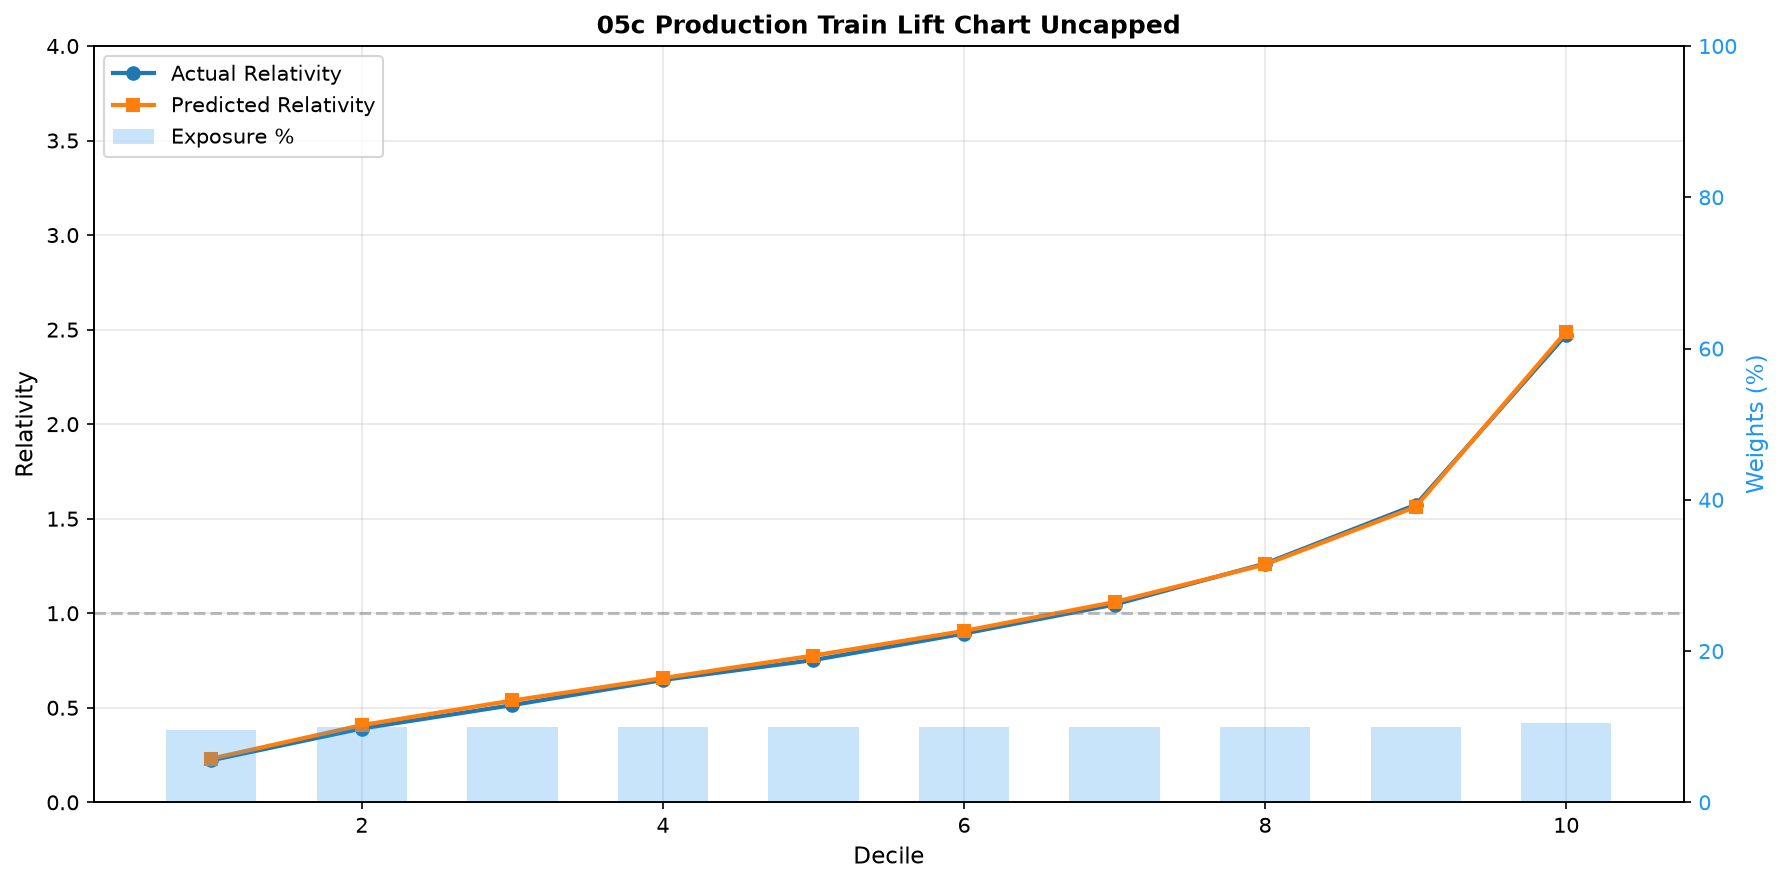


Train decile summary:
 decile  n_records  ee_coll_imps  incurred_act  incurred_pred  act_ee_weigh_avg  act_simple_avg  pred_ee_weigh_avg  pred_simple_avg
      1     275667 195757.631934    9527697.24   9.902623e+06         48.670885       34.562342          50.586141        35.922410
      2     291086 206060.962812   17617350.58   1.842635e+07         85.495818       60.522837          89.421819        63.302069
      3     295142 206060.869242   23205740.40   2.430396e+07        112.615949       78.625680         117.945530        82.346662
      4     299592 206061.009656   29200020.39   2.965124e+07        141.705704       97.465955         143.895452        98.972076
      5     302995 206060.751478   33953558.52   3.503421e+07        164.774506      112.059798         170.018820       115.626349
      6     307402 206060.680979   40276547.08   4.090813e+07        195.459643      131.022398         198.524677       133.076981
      7     312309 206060.819844   47205969.23   4.78

In [21]:
# Train uncapped lift chart
from lift_chart_fast import generate_training_lift_chart

table_train_uncapped = generate_training_lift_chart(
    train_orig,
    pred_train,
    pp_train_actual_uncapped,
    w_train,
    exposure,
    output_base,
    stage='05c',
    dataset='train',
    suffix='_uncapped'
)



* Creating test lift chart_uncapped...
  Creating chart for 3,109,347 rows...
  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 5 columns from 3,109,347 rows...
  [STEP 2] Done in 0.016s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 0.5s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.000s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.027s
  [STEP 5] Aggregating by decile...
  [STEP 5] Done in 0.108s
  Creating plot...
  Plot created in 0.0s
  TOTAL TIME: 0.6s


  Saved: output/car_coll/v1/results/05c_lift_test_uncapped.png


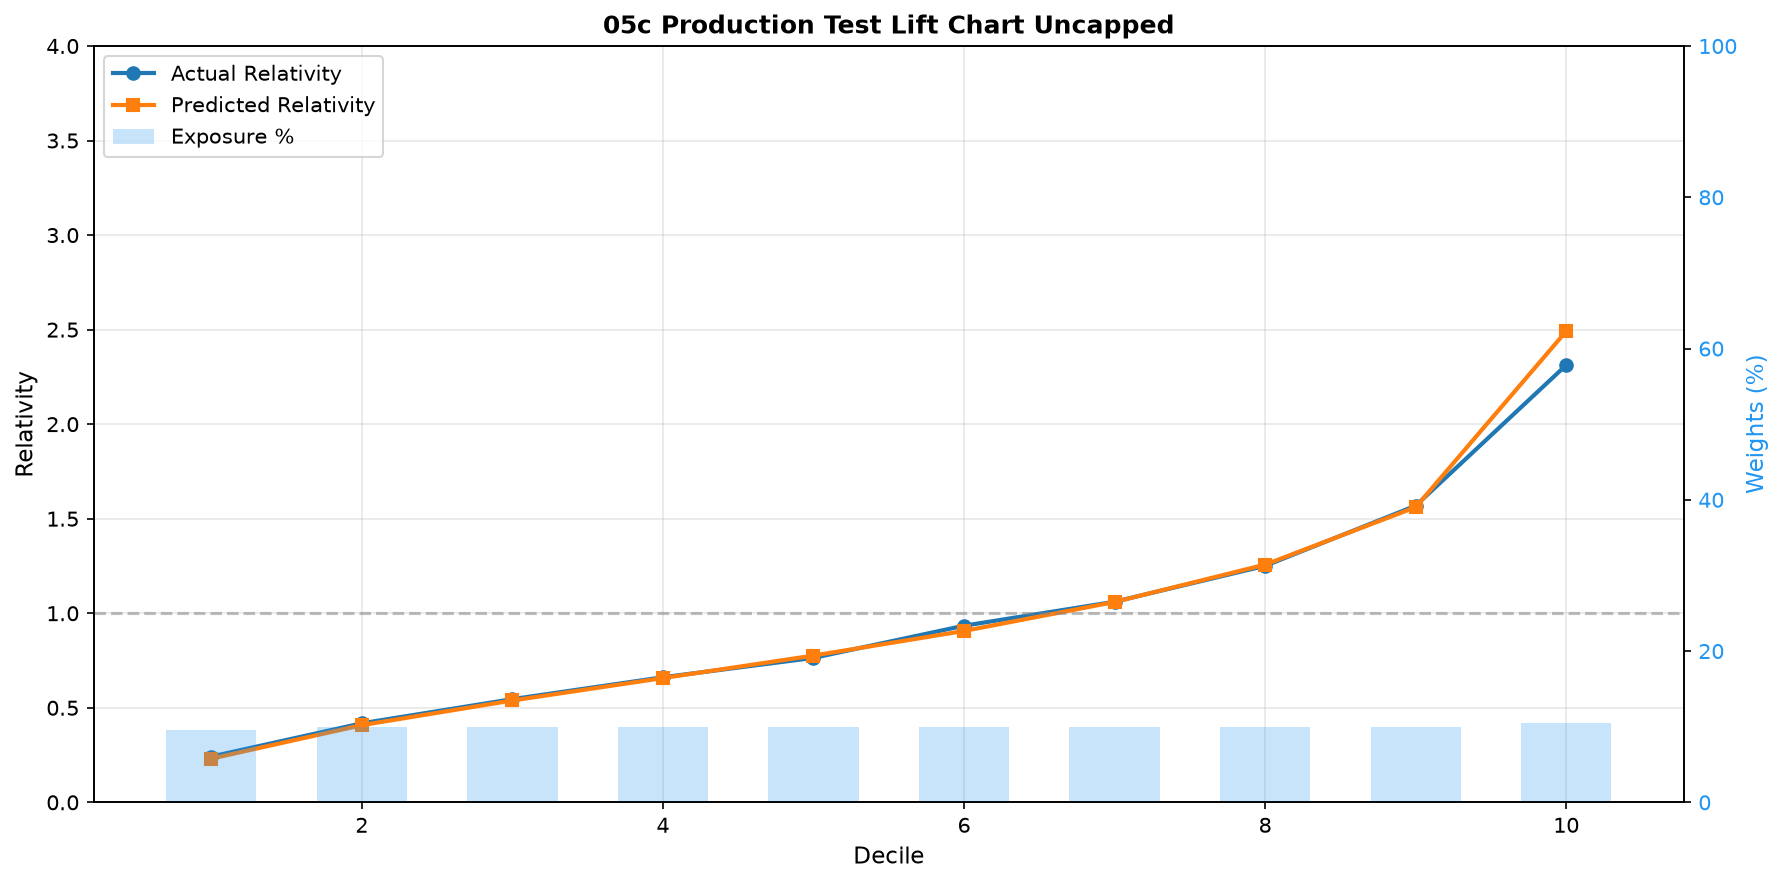


Test decile summary:
 decile  n_records  ee_coll_imps  incurred_act  incurred_pred  act_ee_weigh_avg  act_simple_avg  pred_ee_weigh_avg  pred_simple_avg
      1     274558 194986.469811   10320097.50   9.853741e+06         52.927249       37.588042          50.535512        35.889470
      2     290415 205248.483360   18764174.34   1.832348e+07         91.421744       64.611588          89.274636        63.094136
      3     294595 205249.560064   24499335.52   2.417952e+07        119.363644       83.162768         117.805469        82.077159
      4     298543 205249.465252   29693463.76   2.950090e+07        144.670115       99.461263         143.731911        98.816244
      5     302208 205249.049719   34292274.28   3.484210e+07        167.076409      113.472424         169.755250       115.291798
      6     306143 205249.057452   41928951.76   4.068155e+07        204.283285      136.958715         198.205785       132.884144
      7     311606 205249.212314   47617524.97   4.756

In [22]:
# Test uncapped lift chart
from lift_chart_fast import generate_training_lift_chart

table_test_uncapped = generate_training_lift_chart(
    test_orig,
    pred_test,
    pp_test_actual_uncapped,
    w_test,
    exposure,
    output_base,
    stage='05c',
    dataset='test',
    suffix='_uncapped'
)
